# Minecraft server player activity: engagement & subscription to game-related newsletter

## Data Description

The datasets originated from a UBC Computer Science Minecraft research server, which aims to record player activity and session behaviour for the purpose of studying engagement patterns. Two datasets were provided. Players.csv describes whether they chose to subscribe to a game-related newsletter, and sessions.csv describes how individual players interact with the game environment.

1. Player.csv: This file contains **196 observations** and **7 variables**, with each row representing a unique player. It includes information on player information, play experience, and newsletter subscription.

**Variables**
| Variable | Type | Description | Missing Value |
| --- | --- | --- | --- |
| experience | Numeric | player's self reported gaming experience level | 0 |
| subscribe | Binary | whether the player subscribe to newsletter | 0 |
| hashed mail | Character | encrypted player identifier used to join with session data | 0 |
| played hours | Numeric | total hours played across all sessions | 0 |
| name | Character | player's in-game display name | 0 |
| gender | Character | self reported gender of the player | 0 |
| Age | Numeric | age of the player | 2 |

**Summary Statistics**
| Variable | Mean | Std.Dev | 
| --- | --- | --- |
| played_hours | 5.85 | 28.36 |
| Age | 21.14 | 7.39 |

2. sessions.csv: This file contains **1,535 observations** and **5 variables**, with each row representing a single game session recorded by the server.

**Variables**
| Variable | Type | Description | Missing Value |
| --- | --- | --- | --- |
| hashedEmail | Character | Encrypted player ID | 0 |
| subscribe | Timestamp | recorded session start time | 0 |
| hashed mail | Timestamp | recorded session end time | 2 |
| played hours | Numeric(UNIX) | original timestamp before conversion | 0 |
| name | Numeric(UNIX) | original timestamp before conversion | 2 |

**Summary Statistics**
| Variable |  Mean | Std.Dev | 
| --- | --- |  --- |
| original_start_time | 1.72x10^12 | 3.56x10^9 |
| original_end_time | 1.72x10^12 | 3.55x10^9 |

**Data Issues & Considerations**
- Small number of missing values in Age, end_time, and original_end_time
- extreme outliers in played_hours
- Time variable requires conversion 

## Question

With the rise of online gaming communities, understanding player engagement has become a crucial part of managing servers and designing outreach strategies. knowing what kinds of players are more likely to stay involved in the gaming community. 

Broad Question: 
> What player characteristics and behaviours are most predictive of subscribing to a game-related newsletter, and how do these features differ between various player types?

Specific Question: 
> Can a player’s total playtime (played_hours), age (age), and experience (experience) predict whether they subscribe to the game-related newsletter (subscribe)?

This question focuses on three variables from the data set:
- Total Playtime: cumulative time spent in the game.
- experience: self-reported categorical experience level
- Age
- subscribe: whether they subscribe to game game-related newsletter 

These variables serve as proxies for engagement intensity and habit formation, which may predict the likelihood of remaining involved with the community.                                                                               

## Exploratory Data Analysis and Visualization

1. Setting Up Libraries

In [13]:
library(tidyverse)

2. Load and Merge Data

In [52]:
#Load Data
Players_URL <- "https://raw.githubusercontent.com/symkk79/dsci-100-project-planning-dataset/main/players.csv"
Sessions_URL <- "https://raw.githubusercontent.com/symkk79/dsci-100-project-planning-dataset-1/main/sessions.csv"
players <- read_csv(Players_URL) 
sessions <- read_csv(Sessions_URL)

#mutate experience to proper value
data <- players |> 
    mutate(
    experience = case_when(
    experience == "Beginner" ~ 1,
    experience == "Amateur"  ~ 2,
    experience == "Regular"  ~ 3,
    experience == "Veteran"  ~ 4,
    experience == "Pro"      ~ 5,
    )
  )

data

Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, Age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 1535 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): hashedEmail, start_time, end_time
dbl (2): original_start_time, original_end_time

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


experience,subscribe,hashedEmail,played_hours,name,gender,Age
<dbl>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<dbl>
5,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9
4,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17
4,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17
2,TRUE,23fe711e0e3b77f1da7aa221ab1192afe21648d47d2b4fa7a5a659ff443a0eb5,0.7,Flora,Female,21
3,TRUE,7dc01f10bf20671ecfccdac23812b1b415acd42c2147cb0af4d48fcce2420f3e,0.1,Kylie,Male,21
2,TRUE,f58aad5996a435f16b0284a3b267f973f9af99e7a89bee0430055a44fa92f977,0.0,Adrian,Female,17
3,TRUE,8e594b8953193b26f498db95a508b03c6fe1c24bb5251d392c18a0da9a722807,0.0,Luna,Female,19
2,FALSE,1d2371d8a35c8831034b25bda8764539ab7db0f63938696917c447128a2540dd,0.0,Emerson,Male,21
2,TRUE,8b71f4d66a38389b7528bb38ba6eb71157733df7d1740371852a797ae97d82d1,0.1,Natalie,Male,47


3. Data Summary

In [70]:
data_summary <- data |>
  group_by(subscribe) |>
  summarize(
    count = n(),
    median_age = median(Age, na.rm = TRUE),
    median_played_hours = median(played_hours, na.rm = TRUE),
    median_experience = median(experience, na.rm = TRUE),
    mean_age = mean(Age, na.rm = TRUE),
    mean_played_hours = mean(played_hours, na.rm = TRUE),
    mean_experience = mean(experience, na.rm = TRUE)
  )

data_summary

subscribe,count,median_age,median_played_hours,median_experience,mean_age,mean_played_hours,mean_experience
<lgl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
FALSE,52,21,0.0,2.5,23.7500,0.5019231,2.788462
TRUE,144,19,0.1,2.5,20.1831,7.7756944,2.680556


4. Data Visualization

Warning message:
“Removed 2 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


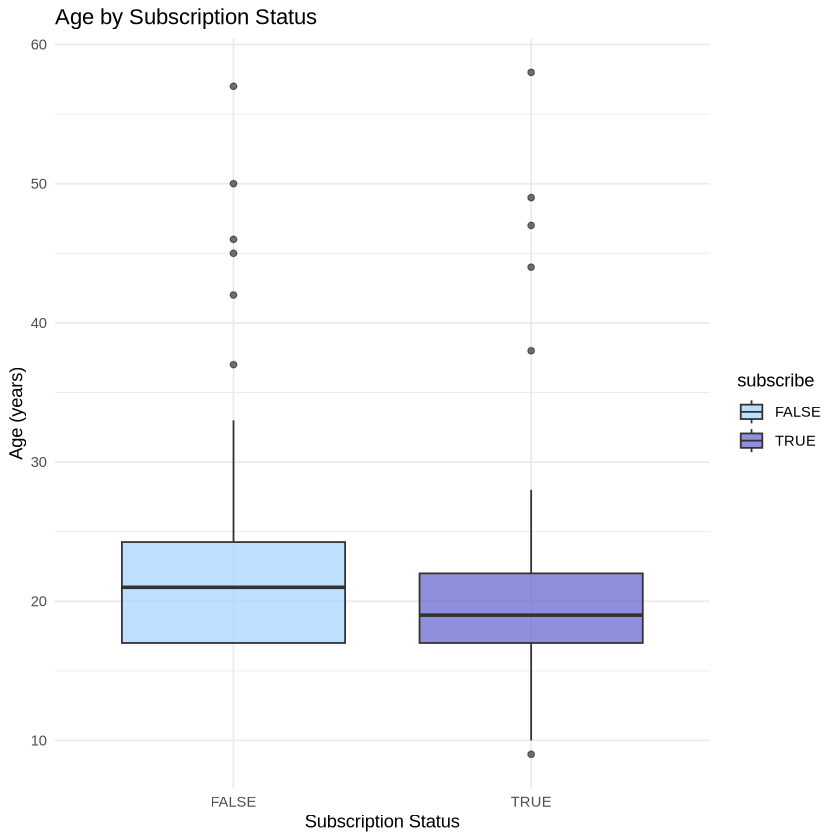

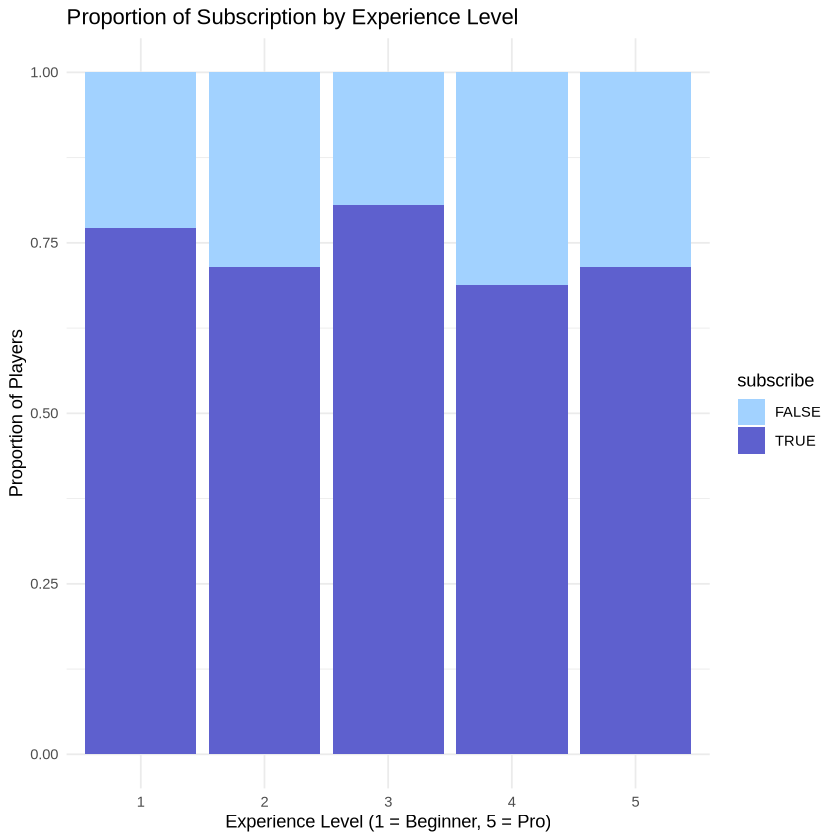

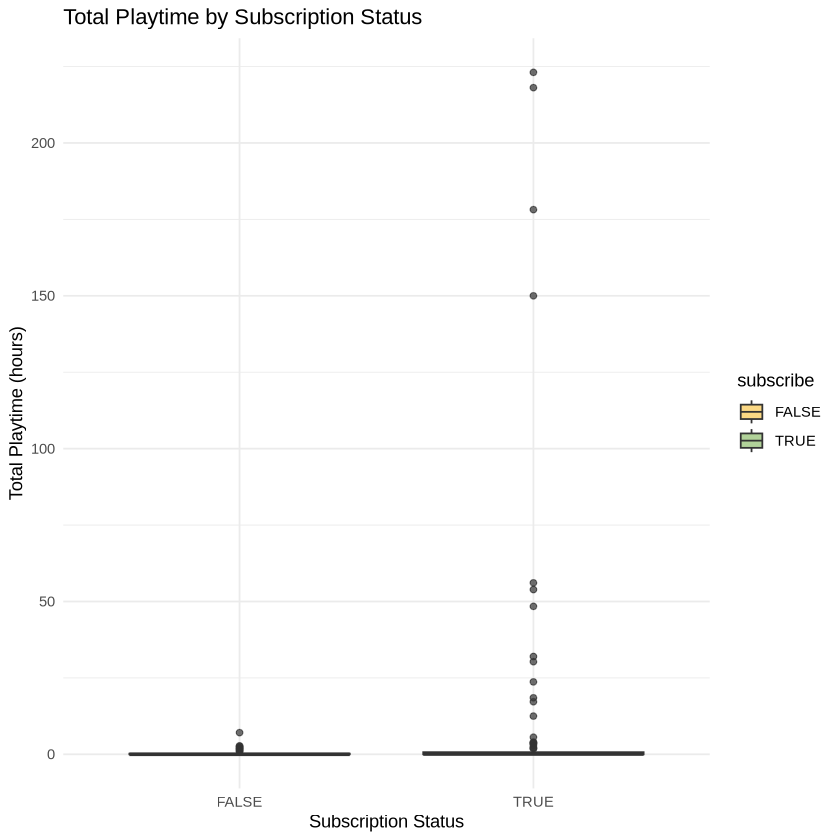

In [71]:
#Age & Subscription
ggplot(data, aes(x = subscribe, y = Age, fill = subscribe)) +
  geom_boxplot(alpha = 0.7) +
  labs(title = "Age by Subscription Status",
       x = "Subscription Status", y = "Age (years)") +
  scale_fill_manual(values = c("#A2D2FF", "#5E60CE")) +
  theme_minimal()

#Experience & Subscription
ggplot(data, aes(x = as.factor(experience), fill = subscribe)) +
  geom_bar(position = "fill") +
  labs(title = "Proportion of Subscription by Experience Level",
       x = "Experience Level (1 = Beginner, 5 = Pro)",
       y = "Proportion of Players") +
  scale_fill_manual(values = c("#A2D2FF", "#5E60CE")) +
  theme_minimal()

#Played Hour & Subscription
ggplot(data, aes(x = subscribe, y = played_hours, fill = subscribe)) +
  geom_boxplot(alpha = 0.7) +
  labs(title = "Total Playtime by Subscription Status",
       x = "Subscription Status", y = "Total Playtime (hours)") +
  scale_fill_manual(values = c("#F9C74F", "#90BE6D")) +
  theme_minimal()


## Methods & Plan

I plan to use a K-Nearest Neighbors classification model to predict newsletter subscription based on player characteristics. 

**Why is it appropriate**
- KNN does not make strict assumptions about the data distribution or linear relationship, which is ideal because the data we have does not show a specific relationship.
- It captures complex, nonlinear patterns in how engagement and players' characteristics relate to subscription behavior.

**Assumptions Required**
KNN assumes:
- The dataset is scaled appropriately so that variables measured on different scales would contribute equally to distance calculation.
- Similar players behave similarly

**Potential limitations** 
- Choice of K(number of neighbors) strongly affects result of prediction 
- sensitive to outliers, where this dataset has a lot of outliers.
- Scaling and normalization of all the variables are important.

**Model comparison & selection**
- For this dataset, we will tune the number of neighbors (k) using 5-fold cross-validation on the training set and choose the model with the highest overall accuracy and balanced precision-recall performance.

**Data processing & splitting plan**
- The dataset will be split into 70% training set and 30% testing set.
- Before fitting the model, we would have to center & scale the numeric predictors to mean 0 and SD1, and filter the outliers to check whether it's necessary.